# LSTM model for satellite imagery time series prediction

For an LSTM next-image model we should use an ordered sequence, not a shuffled batch.

Therefore, we will start with creating an ordered dataloader in the notebook without editing the package source.

We will use this ordered dataloader for a first setup. Later, for real training, we allow `shuffle=True` at the sample level, because each sample already contains its own internal time sequence. But for now, `shuffle=False` will make the notebook easier to reason about and visualize.

## Imports

In [14]:
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from cloudcasting.dataset import SatelliteDataset


torch.manual_seed(0)
np.random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


In [9]:
## load the dataset
train_dataset_ordered = SatelliteDataset(
    zarr_path="../data/2020_training_nonhrv.zarr",
    start_time="2020-06-01",
    end_time="2020-06-19",
    history_mins=60,
    forecast_mins=15,      # predict only the next image
    sample_freq_mins=15,
)

# make a new train dataloader
train_dataloader_ordered = DataLoader(
    train_dataset_ordered,
    batch_size=8,
    shuffle=False,         # important for sequence experiments
    num_workers=0,         # notebook-safe
)

In [3]:
# check the shapes

X, y = next(iter(train_dataloader_ordered))

print("X:", X.shape)
print("y:", y.shape)

X: torch.Size([8, 11, 5, 372, 614])
y: torch.Size([8, 11, 1, 372, 614])


In [5]:
# setup the forecasting parameters

history_mins=60
forecast_mins=15
sample_freq_mins=15

For an LSTM, the main idea will be:

input:  5 previous frames

target: next frame

## LSTM: Mathematical Description

An LSTM processes a sequence one time step at a time. At each time step \(t\), the network receives the current input

$$
x^{\langle t \rangle}
$$

along with the previous hidden state

$$
a^{\langle t-1 \rangle}
$$

and previous cell state

$$
c^{\langle t-1 \rangle}.
$$

The LSTM then computes three gates and a candidate memory state.

### Candidate Cell State

The candidate cell state contains new information that could be added to memory:

$$
\tilde{c}^{\langle t \rangle}
=
\tanh
\left(
W_c
\left[
a^{\langle t-1 \rangle},
x^{\langle t \rangle}
\right]
+
b_c
\right)
$$

### Update Gate

The update gate determines how much of the candidate memory should be written into the cell state:

$$
\Gamma_u
=
\sigma
\left(
W_u
\left[
a^{\langle t-1 \rangle},
x^{\langle t \rangle}
\right]
+
b_u
\right)
$$

### Forget Gate

The forget gate determines how much of the previous memory should be retained:

$$
\Gamma_f
=
\sigma
\left(
W_f
\left[
a^{\langle t-1 \rangle},
x^{\langle t \rangle}
\right]
+
b_f
\right)
$$

### Output Gate

The output gate controls what information becomes visible in the hidden state:

$$
\Gamma_o
=
\sigma
\left(
W_o
\left[
a^{\langle t-1 \rangle},
x^{\langle t \rangle}
\right]
+
b_o
\right)
$$

### Cell State Update

The new cell state combines information from the previous memory and the candidate memory:

$$
c^{\langle t \rangle}
=
\Gamma_u
*
\tilde{c}^{\langle t \rangle}
+
\Gamma_f
*
c^{\langle t-1 \rangle}
$$

### Hidden State Update

The hidden state is computed from the updated cell state:

$$
a^{\langle t \rangle}
=
\Gamma_o
*
\tanh
\left(
c^{\langle t \rangle}
\right)
$$

### Notation

- x<t> : current input image or feature vector at time step t
- a<t> : hidden state at time step t
- c<t> : cell state (memory) at time step t
- Γf : forget gate
- Γu : update (input) gate
- Γo : output gate
- σ : sigmoid activation function
- tanh : hyperbolic tangent activation function

For satellite image forecasting, the input x<t> is typically a satellite image (or an encoded representation of an image) observed at time step t. The hidden state a<t> and cell state c<t> allow the network to remember how cloud patterns evolve through time, enabling prediction of future cloud locations and structures.
For satellite image forecasting, the sequence of satellite images is fed into the LSTM. The hidden state and cell state learn how cloud patterns evolve over time, allowing the network to predict future cloud locations and structures.

## Preparing Satellite Images for an LSTM

Unlike traditional machine learning models, an LSTM expects a sequence of vectors as input. However, our satellite observations are images with dimensions:

$$
(H, W)
$$

or, when multiple channels are used,

$$
(H, W, C)
$$

where:

* (H) is the image height,
* (W) is the image width,
* (C) is the number of channels.


The main ML approaches to processing imagery with LSTMs are:

- The simplest approach: flatten image -> LSTM
- Better: CNN encoder -> LSTM -> CNN decoder
- Best first choice for image sequences: ConvLSTM

Therefore, the best approach will be using a **ConvLSTM**

ConvLSTM replaces the dense matrix multiplications inside an LSTM with convolutions.

Standard LSTM:

input vector -> matrix multiplication

ConvLSTM:

input image -> convolution

This means the model keeps the image layout and learns local cloud motion patterns. ConvLSTM was introduced for precipitation nowcasting by Shi et al. and is a standard baseline for spatiotemporal weather prediction. Paper: Shi et al., 2015, ConvLSTM for precipitation nowcasting.

## From LSTM to ConvLSTM

For satellite image prediction, we will use a **Convolutional LSTM**, or **ConvLSTM**, introduced by Shi et al. in their 2015 paper on precipitation nowcasting.

The key idea is simple: instead of flattening each image into a long vector, ConvLSTM keeps the image as a two-dimensional spatial field.

A standard LSTM receives inputs such as:

```text
(batch, time, features)
```

A ConvLSTM receives image sequences such as:

```text
(batch, time, channels, height, width)
```

This is much better suited to satellite imagery because clouds have spatial structure. Nearby pixels are related to each other, and cloud systems move across the image over time.

## Why ConvLSTM?

A regular LSTM can model temporal patterns, but flattening the image destroys much of the spatial structure. ConvLSTM avoids this by replacing the matrix multiplications inside the LSTM gates with convolution operations.

This means the model learns:

* how cloud patterns change over time,
* how nearby pixels influence each other,
* how spatial structures such as cloud edges, fronts, and clusters evolve.

ConvLSTM is therefore a natural model for nowcasting tasks, where the goal is to predict future spatial fields from past spatial fields.

## ConvLSTM Input

In our case, each training example will be a sequence of satellite images:

```text
x<1>, x<2>, ..., x<T>
```

Each image has shape:

```text
channels × height × width
```

The model receives the past frames and learns to predict a future frame, for example:

```text
past satellite images  →  next satellite image
```

or:

```text
past satellite images  →  several future satellite images
```

## ConvLSTM Cell

The ConvLSTM cell uses the same gates as an LSTM:

```text
Γf : forget gate
Γu : update gate
Γo : output gate
c~<t> : candidate cell state
c<t> : cell state
a<t> : hidden state
```

The difference is that the gates are computed using convolutions rather than fully connected layers.

This allows the hidden state and cell state to remain image-like tensors with spatial dimensions:

```text
hidden channels × height × width
```

As a result, the model can preserve spatial information while learning temporal dynamics.

## Why This Matters for Satellite Imagery

Satellite image forecasting is a spatiotemporal prediction problem. The model must learn both where clouds are and how they move.

ConvLSTM is designed for this type of task. It was originally proposed for precipitation nowcasting, where the goal is to predict future rainfall maps from previous radar observations. This is closely related to our cloudcasting task, where we predict future satellite images from previous satellite images.

In this tutorial, we will use ConvLSTM as a stronger baseline than a plain LSTM because it respects the image structure of the data while still modelling temporal evolution.


### Reference

Shi, X., Chen, Z., Wang, H., Yeung, D.-Y., Wong, W.-K., & Woo, W.-C. (2015).
*Convolutional LSTM Network: A Machine Learning Approach for Precipitation Nowcasting.*

Available at: https://arxiv.org/abs/1506.04214

For our dataset, we will do the following steps:

1. Single-channel ConvLSTM using `VIS008` only
2. Predict the next `VIS008` image
3. Then extend to all 11 channels

The architecture will look as following:

Input sequence

    ↓
    
ConvLSTM layer

    ↓
    
Final hidden state

    ↓
    
2D convolution

    ↓
    
Predicted next image

## Inspect One Batch From the Ordered Dataloader

In [10]:
X, y = next(iter(train_dataloader_ordered))

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

X shape: torch.Size([8, 11, 5, 372, 614])
y shape: torch.Size([8, 11, 1, 372, 614])
X dtype: torch.float32
y dtype: torch.float32


### Select One Channel And Rearrange For ConvLSTM

We’ll start with `VIS008` only, channel index 8.

Current shape:

X: [batch, channels, time, height, width]

For ConvLSTM, we want:

X_vis: [batch, time, channels, height, width]

In [11]:
channel_index = 8  # VIS008

X_vis = X[:, channel_index:channel_index + 1, :, :, :]
y_vis = y[:, channel_index:channel_index + 1, :, :, :]

# Rearrange X from [batch, channel, time, height, width]
# to [batch, time, channel, height, width]
X_vis = X_vis.permute(0, 2, 1, 3, 4)

# Target: remove the forecast time dimension
# from [batch, channel, 1, height, width]
# to [batch, channel, height, width]
y_vis = y_vis[:, :, 0, :, :]

print("X_vis shape:", X_vis.shape)
print("y_vis shape:", y_vis.shape)

X_vis shape: torch.Size([8, 5, 1, 372, 614])
y_vis shape: torch.Size([8, 1, 372, 614])


Downsample Images 

For the first LSTM model, we’ll downsample to 96 x 160. This keeps the cloud structure but makes training much faster.

In [12]:
import torch.nn.functional as F

target_size = (96, 160)

batch_size, seq_len, channels, height, width = X_vis.shape

# Merge batch and time so interpolate can resize all frames at once
X_small = X_vis.reshape(batch_size * seq_len, channels, height, width)

X_small = F.interpolate(
    X_small,
    size=target_size,
    mode="bilinear",
    align_corners=False,
)

# Restore sequence shape: [batch, time, channel, height, width]
X_small = X_small.reshape(batch_size, seq_len, channels, *target_size)

y_small = F.interpolate(
    y_vis,
    size=target_size,
    mode="bilinear",
    align_corners=False,
)

print("X_small shape:", X_small.shape)
print("y_small shape:", y_small.shape)

X_small shape: torch.Size([8, 5, 1, 96, 160])
y_small shape: torch.Size([8, 1, 96, 160])


### Define A ConvLSTM Cell

This is the LSTM math, but using convolutions instead of dense matrix multiplications.

In [15]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size=3):
        super().__init__()

        padding = kernel_size // 2
        self.hidden_channels = hidden_channels

        self.conv = nn.Conv2d(
            in_channels=input_channels + hidden_channels,
            out_channels=4 * hidden_channels,
            kernel_size=kernel_size,
            padding=padding,
        )

    def forward(self, x_t, h_prev, c_prev):
        # x_t:    [batch, input_channels, height, width]
        # h_prev: [batch, hidden_channels, height, width]
        # c_prev: [batch, hidden_channels, height, width]

        combined = torch.cat([x_t, h_prev], dim=1)

        gates = self.conv(combined)

        input_gate, forget_gate, output_gate, candidate = torch.chunk(
            gates,
            chunks=4,
            dim=1,
        )

        input_gate = torch.sigmoid(input_gate)
        forget_gate = torch.sigmoid(forget_gate)
        output_gate = torch.sigmoid(output_gate)
        candidate = torch.tanh(candidate)

        c_next = forget_gate * c_prev + input_gate * candidate
        h_next = output_gate * torch.tanh(c_next)

        return h_next, c_next

### Define The ConvLSTM Forecasting Model

In [16]:
class ConvLSTMNextFrame(nn.Module):
    def __init__(self, input_channels=1, hidden_channels=16, kernel_size=3):
        super().__init__()

        self.hidden_channels = hidden_channels

        self.convlstm_cell = ConvLSTMCell(
            input_channels=input_channels,
            hidden_channels=hidden_channels,
            kernel_size=kernel_size,
        )

        self.output_conv = nn.Conv2d(
            in_channels=hidden_channels,
            out_channels=1,
            kernel_size=1,
        )

    def forward(self, x):
        # x shape: [batch, time, channels, height, width]

        batch_size, seq_len, channels, height, width = x.shape

        h = torch.zeros(
            batch_size,
            self.hidden_channels,
            height,
            width,
            device=x.device,
        )

        c = torch.zeros(
            batch_size,
            self.hidden_channels,
            height,
            width,
            device=x.device,
        )

        for t in range(seq_len):
            h, c = self.convlstm_cell(x[:, t], h, c)

        prediction = self.output_conv(h)

        return prediction

### Create The Model And Test One Forward Pass

In [17]:
model = ConvLSTMNextFrame(
    input_channels=1,
    hidden_channels=16,
    kernel_size=3,
).to(device)

X_small = X_small.to(device)
y_small = y_small.to(device)

with torch.no_grad():
    y_pred = model(X_small)

print("Prediction shape:", y_pred.shape)
print("Target shape:", y_small.shape)

Prediction shape: torch.Size([8, 1, 96, 160])
Target shape: torch.Size([8, 1, 96, 160])


## Define Loss and Optimizer

For next-image prediction, we will start with the **Mean Squared Error (MSE)** loss function:

$$
\text{MSE}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(
\hat{y}_i - y_i
\right)^2
$$

where:

- \(N\) is the number of predicted pixels,
- \(\hat{y}_i\) is the predicted pixel value,
- \(y_i\) is the true pixel value.

MSE penalizes large prediction errors more strongly than small errors and is commonly used for image reconstruction and forecasting tasks.

In [19]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

In [20]:
model.train()

y_pred = model(X_small)
loss = loss_fn(y_pred, y_small)

print("Initial loss:", loss.item())

Initial loss: nan


In [21]:
print("NaNs in X_small:", torch.isnan(X_small).sum().item())
print("NaNs in y_small:", torch.isnan(y_small).sum().item())

print("Finite values in X_small:", torch.isfinite(X_small).sum().item())
print("Finite values in y_small:", torch.isfinite(y_small).sum().item())

NaNs in X_small: 27830
NaNs in y_small: 6160
Finite values in X_small: 586570
Finite values in y_small: 116720


Replace NaNs With Zero

In [22]:
X_small_clean = torch.nan_to_num(
    X_small,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)

y_small_clean = torch.nan_to_num(
    y_small,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
)

print("NaNs in X_small_clean:", torch.isnan(X_small_clean).sum().item())
print("NaNs in y_small_clean:", torch.isnan(y_small_clean).sum().item())

NaNs in X_small_clean: 0
NaNs in y_small_clean: 0


In [23]:
model.train()

y_pred = model(X_small_clean)
loss = loss_fn(y_pred, y_small_clean)

print("Initial clean loss:", loss.item())

Initial clean loss: 0.009793732315301895


Train On This One Batch For A Few Steps

In [24]:
model.train()

num_steps = 20
losses = []

for step in range(num_steps):
    optimizer.zero_grad()

    y_pred = model(X_small_clean)
    loss = loss_fn(y_pred, y_small_clean)

    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    print(f"Step {step + 1:02d} | loss: {loss.item():.6f}")

Step 01 | loss: 0.009794
Step 02 | loss: 0.008949
Step 03 | loss: 0.008196
Step 04 | loss: 0.007522
Step 05 | loss: 0.006916
Step 06 | loss: 0.006367
Step 07 | loss: 0.005865
Step 08 | loss: 0.005405
Step 09 | loss: 0.004981
Step 10 | loss: 0.004587
Step 11 | loss: 0.004220
Step 12 | loss: 0.003877
Step 13 | loss: 0.003554
Step 14 | loss: 0.003250
Step 15 | loss: 0.002963
Step 16 | loss: 0.002690
Step 17 | loss: 0.002432
Step 18 | loss: 0.002186
Step 19 | loss: 0.001953
Step 20 | loss: 0.001732


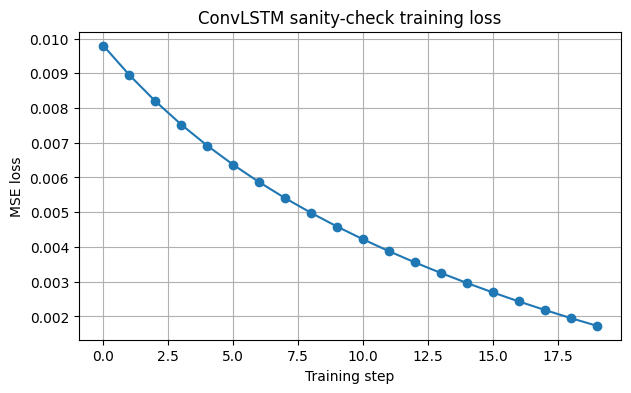

In [25]:
# Plot The Training Loss

plt.figure(figsize=(7, 4))
plt.plot(losses, marker="o")
plt.xlabel("Training step")
plt.ylabel("MSE loss")
plt.title("ConvLSTM sanity-check training loss")
plt.grid(True)
plt.show()

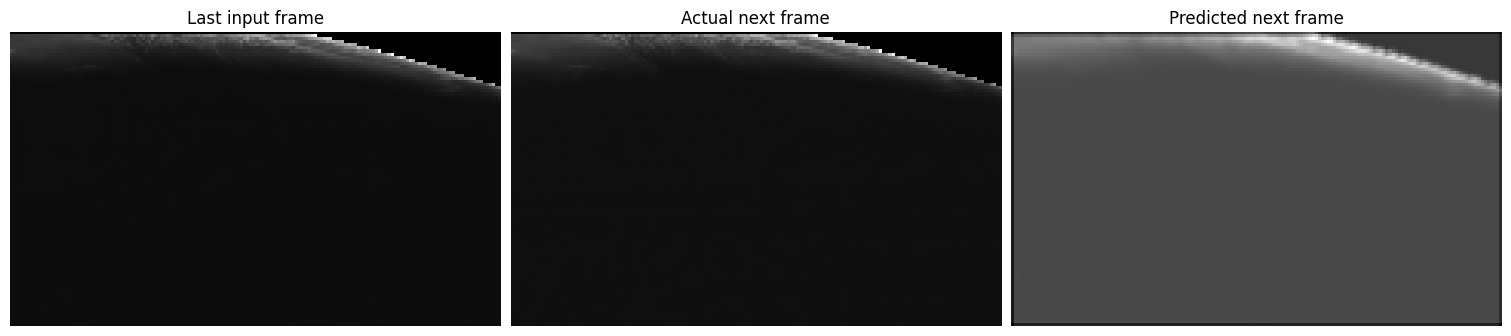

In [27]:
## Compare Input, Target, And Prediction

model.eval()

with torch.no_grad():
    y_pred = model(X_small_clean)

sample_index = 0

last_input = X_small_clean[sample_index, -1, 0].detach().cpu().numpy()
target = y_small_clean[sample_index, 0].detach().cpu().numpy()
prediction = y_pred[sample_index, 0].detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].imshow(last_input, cmap="gray", origin="lower")
axes[0].set_title("Last input frame")

axes[1].imshow(target, cmap="gray", origin="lower")
axes[1].set_title("Actual next frame")

axes[2].imshow(prediction, cmap="gray", origin="lower")
axes[2].set_title("Predicted next frame")

for ax in axes:
    ax.axis("off")

plt.show()

The images above are dark: our dataloader starts with the imagery at 12 am UK time.

### Create A Daytime Ordered Dataloader

Let’s use midday UK imagery:

In [28]:
daytime_dataset = SatelliteDataset(
    zarr_path="../data/2020_training_nonhrv.zarr",
    start_time="2020-06-01 10:00",
    end_time="2020-06-05 16:00",
    history_mins=60,
    forecast_mins=15,
    sample_freq_mins=15,
)

daytime_loader = DataLoader(
    daytime_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
)

X_day, y_day = next(iter(daytime_loader))

print("X_day shape:", X_day.shape)
print("y_day shape:", y_day.shape)

X_day shape: torch.Size([8, 11, 5, 372, 614])
y_day shape: torch.Size([8, 11, 1, 372, 614])


In [29]:
# run the same preprocessing on this daytime batch:

channel_index = 8  # VIS008

X_day_vis = X_day[:, channel_index:channel_index + 1]
y_day_vis = y_day[:, channel_index:channel_index + 1]

X_day_vis = X_day_vis.permute(0, 2, 1, 3, 4)
y_day_vis = y_day_vis[:, :, 0]

batch_size, seq_len, channels, height, width = X_day_vis.shape

X_day_small = X_day_vis.reshape(batch_size * seq_len, channels, height, width)

X_day_small = F.interpolate(
    X_day_small,
    size=target_size,
    mode="bilinear",
    align_corners=False,
)

X_day_small = X_day_small.reshape(batch_size, seq_len, channels, *target_size)

y_day_small = F.interpolate(
    y_day_vis,
    size=target_size,
    mode="bilinear",
    align_corners=False,
)

X_day_small_clean = torch.nan_to_num(X_day_small, nan=0.0, posinf=0.0, neginf=0.0).to(device)
y_day_small_clean = torch.nan_to_num(y_day_small, nan=0.0, posinf=0.0, neginf=0.0).to(device)

print("X_day_small_clean:", X_day_small_clean.shape)
print("y_day_small_clean:", y_day_small_clean.shape)

X_day_small_clean: torch.Size([8, 5, 1, 96, 160])
y_day_small_clean: torch.Size([8, 1, 96, 160])


In [31]:
## Reinitialize And Train On The Daytime Batch

model_day = ConvLSTMNextFrame(
    input_channels=1,
    hidden_channels=16,
    kernel_size=3,
).to(device)

loss_fn = nn.MSELoss()

optimizer_day = torch.optim.Adam(
    model_day.parameters(),
    lr=1e-3,
)

model_day.train()

num_steps = 30
day_losses = []

for step in range(num_steps):
    optimizer_day.zero_grad()

    y_day_pred = model_day(X_day_small_clean)
    loss = loss_fn(y_day_pred, y_day_small_clean)

    loss.backward()
    optimizer_day.step()

    day_losses.append(loss.item())

    print(f"Step {step + 1:02d} | loss: {loss.item():.6f}")

Step 01 | loss: 0.200031
Step 02 | loss: 0.192851
Step 03 | loss: 0.186149
Step 04 | loss: 0.179871
Step 05 | loss: 0.173957
Step 06 | loss: 0.168344
Step 07 | loss: 0.162971
Step 08 | loss: 0.157782
Step 09 | loss: 0.152725
Step 10 | loss: 0.147755
Step 11 | loss: 0.142822
Step 12 | loss: 0.137879
Step 13 | loss: 0.132874
Step 14 | loss: 0.127752
Step 15 | loss: 0.122455
Step 16 | loss: 0.116919
Step 17 | loss: 0.111076
Step 18 | loss: 0.104852
Step 19 | loss: 0.098172
Step 20 | loss: 0.090956
Step 21 | loss: 0.083130
Step 22 | loss: 0.074632
Step 23 | loss: 0.065424
Step 24 | loss: 0.055528
Step 25 | loss: 0.045059
Step 26 | loss: 0.034299
Step 27 | loss: 0.023788
Step 28 | loss: 0.014453
Step 29 | loss: 0.007713
Step 30 | loss: 0.005391


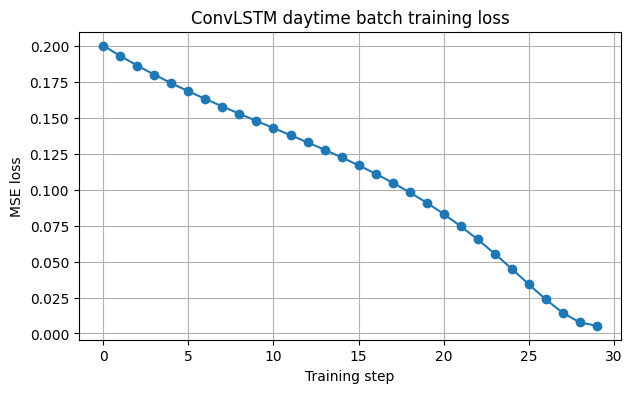

In [32]:
# Plot Daytime Training Loss

plt.figure(figsize=(7, 4))
plt.plot(day_losses, marker="o")
plt.xlabel("Training step")
plt.ylabel("MSE loss")
plt.title("ConvLSTM daytime batch training loss")
plt.grid(True)
plt.show()

## Next step: Plot Last Input, Actual Next Image, And Prediction

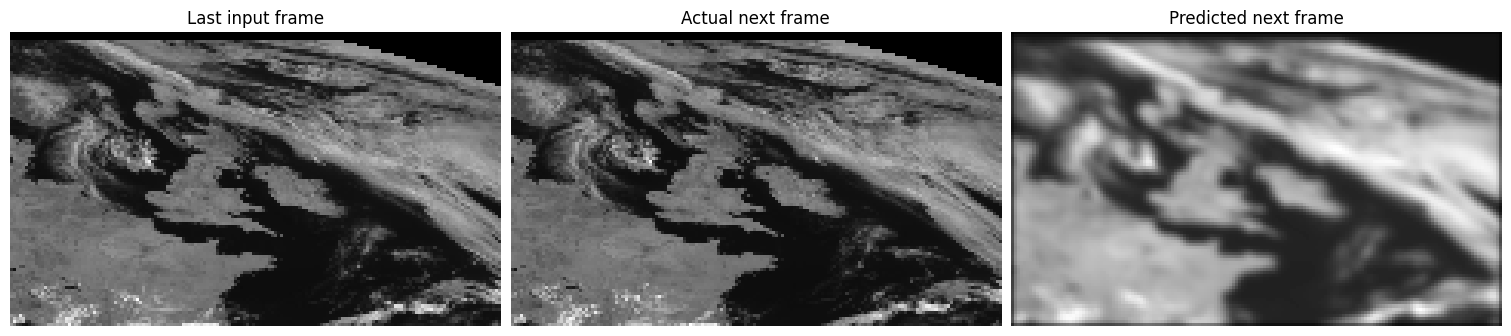

In [33]:
model_day.eval()

with torch.no_grad():
    y_day_pred = model_day(X_day_small_clean)

sample_index = 0

last_input = X_day_small_clean[sample_index, -1, 0].detach().cpu().numpy()
target = y_day_small_clean[sample_index, 0].detach().cpu().numpy()
prediction = y_day_pred[sample_index, 0].detach().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].imshow(last_input, cmap="gray", origin="lower")
axes[0].set_title("Last input frame")

axes[1].imshow(target, cmap="gray", origin="lower")
axes[1].set_title("Actual next frame")

axes[2].imshow(prediction, cmap="gray", origin="lower")
axes[2].set_title("Predicted next frame")

for ax in axes:
    ax.axis("off")

plt.show()

## Train On Multiple Daytime Batches

In [38]:
model_day = ConvLSTMNextFrame(
    input_channels=1,
    hidden_channels=16,
    kernel_size=3,
).to(device)

optimizer_day = torch.optim.Adam(
    model_day.parameters(),
    lr=1e-3,
)

loss_fn = nn.MSELoss()

num_epochs = 15
epoch_losses = []

for epoch in range(num_epochs):
    model_day.train()
    batch_losses = []

    for X_batch, y_batch in daytime_loader:
        # Select VIS008
        X_batch = X_batch[:, channel_index:channel_index + 1]
        y_batch = y_batch[:, channel_index:channel_index + 1]

        # [batch, channel, time, height, width]
        # -> [batch, time, channel, height, width]
        X_batch = X_batch.permute(0, 2, 1, 3, 4)
        y_batch = y_batch[:, :, 0]

        batch_size, seq_len, channels, height, width = X_batch.shape

        # Resize X
        X_batch_small = X_batch.reshape(batch_size * seq_len, channels, height, width)
        X_batch_small = F.interpolate(
            X_batch_small,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )
        X_batch_small = X_batch_small.reshape(
            batch_size,
            seq_len,
            channels,
            *target_size,
        )

        # Resize y
        y_batch_small = F.interpolate(
            y_batch,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )

        # Clean NaNs
        X_batch_small = torch.nan_to_num(
            X_batch_small,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        ).to(device)

        y_batch_small = torch.nan_to_num(
            y_batch_small,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        ).to(device)

        optimizer_day.zero_grad()

        y_pred = model_day(X_batch_small)
        loss = loss_fn(y_pred, y_batch_small)

        loss.backward()
        optimizer_day.step()

        batch_losses.append(loss.item())

    mean_loss = np.mean(batch_losses)
    epoch_losses.append(mean_loss)

    print(f"Epoch {epoch + 1}/{num_epochs} | mean loss: {mean_loss:.6f}")

Epoch 1/15 | mean loss: 0.013358
Epoch 2/15 | mean loss: 0.004703
Epoch 3/15 | mean loss: 0.003752
Epoch 4/15 | mean loss: 0.003513
Epoch 5/15 | mean loss: 0.003350
Epoch 6/15 | mean loss: 0.003502
Epoch 7/15 | mean loss: 0.003294
Epoch 8/15 | mean loss: 0.002768
Epoch 9/15 | mean loss: 0.003093
Epoch 10/15 | mean loss: 0.002883
Epoch 11/15 | mean loss: 0.002142
Epoch 12/15 | mean loss: 0.001977
Epoch 13/15 | mean loss: 0.001804
Epoch 14/15 | mean loss: 0.001726
Epoch 15/15 | mean loss: 0.001577


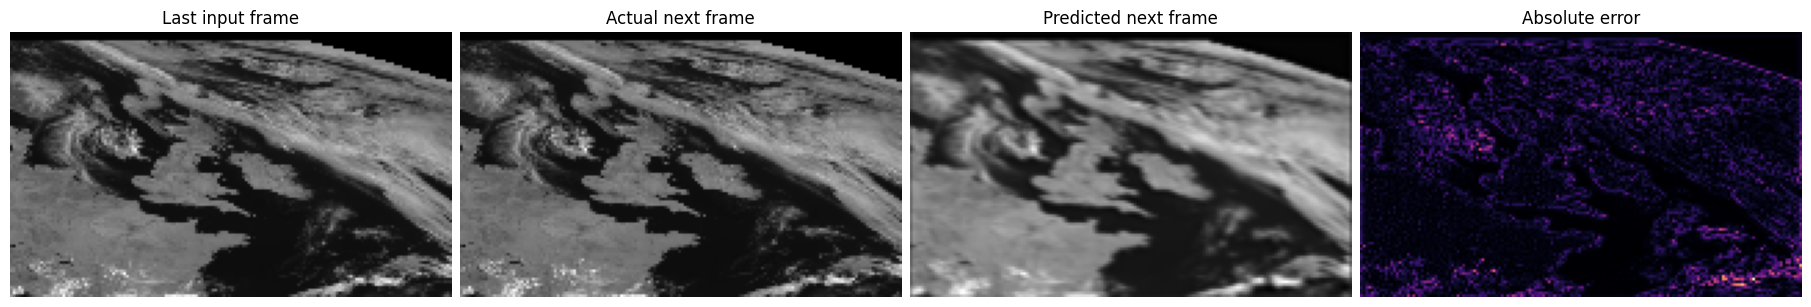

In [39]:
model_day.eval()

X_eval, y_eval = next(iter(daytime_loader))

# Select VIS008
X_eval = X_eval[:, channel_index:channel_index + 1]
y_eval = y_eval[:, channel_index:channel_index + 1]

# Rearrange
X_eval = X_eval.permute(0, 2, 1, 3, 4)
y_eval = y_eval[:, :, 0]

batch_size, seq_len, channels, height, width = X_eval.shape

# Resize X
X_eval_small = X_eval.reshape(batch_size * seq_len, channels, height, width)
X_eval_small = F.interpolate(
    X_eval_small,
    size=target_size,
    mode="bilinear",
    align_corners=False,
)
X_eval_small = X_eval_small.reshape(
    batch_size,
    seq_len,
    channels,
    *target_size,
)

# Resize y
y_eval_small = F.interpolate(
    y_eval,
    size=target_size,
    mode="bilinear",
    align_corners=False,
)

# Clean NaNs
X_eval_small = torch.nan_to_num(
    X_eval_small,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
).to(device)

y_eval_small = torch.nan_to_num(
    y_eval_small,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
).to(device)

with torch.no_grad():
    y_eval_pred = model_day(X_eval_small)

sample_index = 0

last_input = X_eval_small[sample_index, -1, 0].detach().cpu().numpy()
target = y_eval_small[sample_index, 0].detach().cpu().numpy()
prediction = y_eval_pred[sample_index, 0].detach().cpu().numpy()
error = np.abs(target - prediction)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), constrained_layout=True)

axes[0].imshow(last_input, cmap="gray", origin="lower")
axes[0].set_title("Last input frame")

axes[1].imshow(target, cmap="gray", origin="lower")
axes[1].set_title("Actual next frame")

axes[2].imshow(prediction, cmap="gray", origin="lower")
axes[2].set_title("Predicted next frame")

axes[3].imshow(error, cmap="magma", origin="lower")
axes[3].set_title("Absolute error")

for ax in axes:
    ax.axis("off")

plt.show()

The clean next improvement is to add a persistence baseline before making the model more complex.

Persistence means:

predict next image = last input image

In [40]:
persistence = X_eval_small[:, -1]  # last input frame

mse_model = loss_fn(y_eval_pred, y_eval_small).item()
mse_persistence = loss_fn(persistence, y_eval_small).item()

print("ConvLSTM MSE:", mse_model)
print("Persistence MSE:", mse_persistence)

ConvLSTM MSE: 0.001637287437915802
Persistence MSE: 0.0009208542760461569


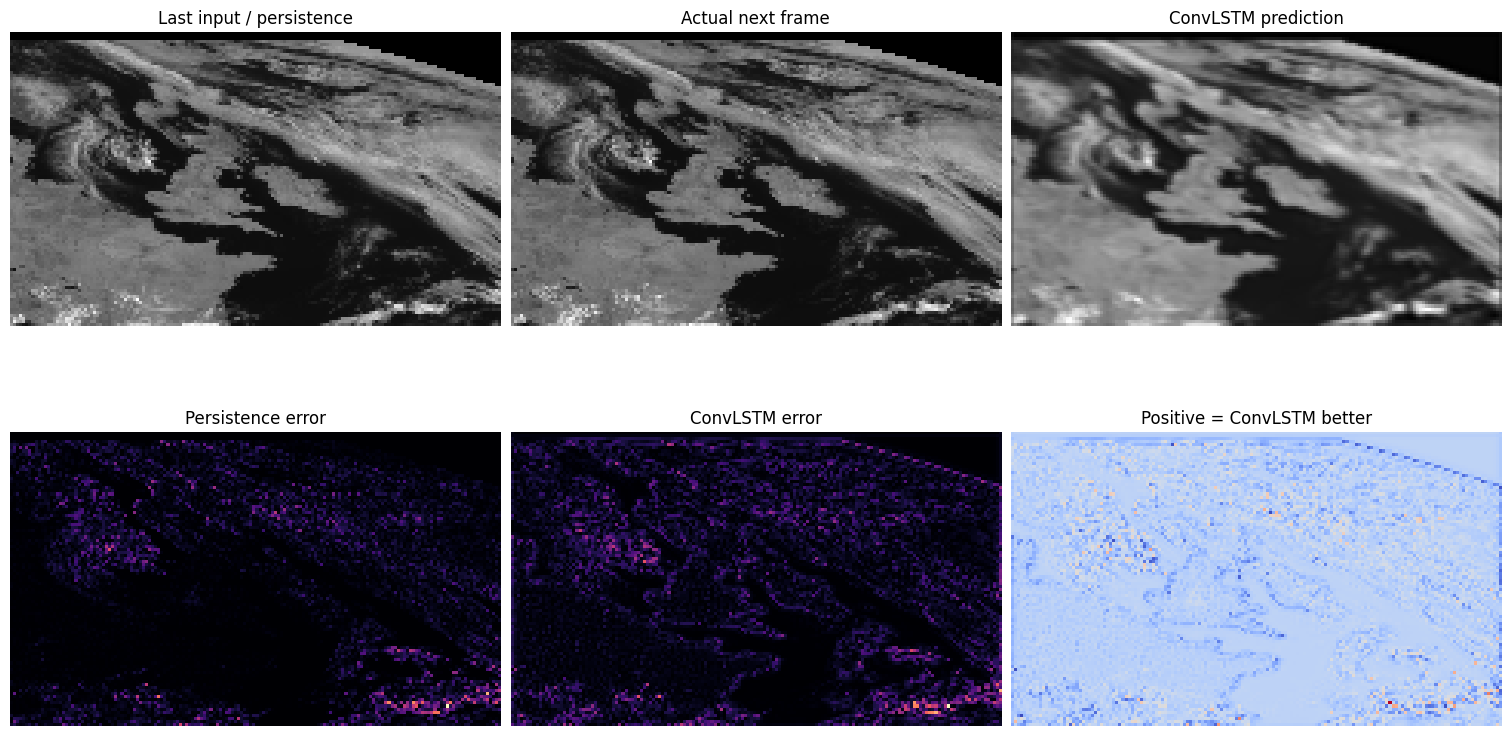

In [41]:
sample_index = 0

last_input = X_eval_small[sample_index, -1, 0].detach().cpu().numpy()
target = y_eval_small[sample_index, 0].detach().cpu().numpy()
prediction = y_eval_pred[sample_index, 0].detach().cpu().numpy()
persistence_pred = persistence[sample_index, 0].detach().cpu().numpy()

error_model = np.abs(target - prediction)
error_persistence = np.abs(target - persistence_pred)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

axes[0, 0].imshow(last_input, cmap="gray", origin="lower")
axes[0, 0].set_title("Last input / persistence")

axes[0, 1].imshow(target, cmap="gray", origin="lower")
axes[0, 1].set_title("Actual next frame")

axes[0, 2].imshow(prediction, cmap="gray", origin="lower")
axes[0, 2].set_title("ConvLSTM prediction")

axes[1, 0].imshow(error_persistence, cmap="magma", origin="lower")
axes[1, 0].set_title("Persistence error")

axes[1, 1].imshow(error_model, cmap="magma", origin="lower")
axes[1, 1].set_title("ConvLSTM error")

axes[1, 2].imshow(error_persistence - error_model, cmap="coolwarm", origin="lower")
axes[1, 2].set_title("Positive = ConvLSTM better")

for ax in axes.ravel():
    ax.axis("off")

plt.show()

## Residual ConvLSTM: Learning Changes Instead of Images

A straightforward approach is to train a ConvLSTM to directly predict the next satellite image:

$$
\hat{y}_{t+1} = f_\theta(x_{t-4}, x_{t-3}, x_{t-2}, x_{t-1}, x_t)
$$

where:

- x_t = most recent input image
- f_theta = ConvLSTM model
- y_hat_(t+1) = predicted next image

However, satellite images often change only gradually over short time intervals. A strong baseline is therefore **persistence forecasting**, which assumes that the next image is identical to the most recent image:

$$
\hat{y}_{t+1} = x_t
$$

### Residual Learning

Instead of predicting the entire next image, we ask the ConvLSTM to predict only the change between the current image and the future image.

The model predicts a residual field:

$$
r_{t+1} = f_\theta(x_{t-4}, x_{t-3}, x_{t-2}, x_{t-1}, x_t)
$$

The final forecast is then:

$$
\hat{y}_{t+1} = x_t + r_{t+1}
$$

or equivalently:

$$
\hat{y}_{t+1}
=
x_t
+
f_\theta(x_{t-4}, x_{t-3}, x_{t-2}, x_{t-1}, x_t)
$$

### Why Residual Learning Helps

The ConvLSTM no longer needs to reconstruct the entire image. Instead, it only learns:

- cloud motion,
- cloud growth,
- cloud decay,
- appearance of new clouds,
- disappearance of existing clouds.

This is often much easier because most pixels change only slightly between consecutive observations.

### Relationship to Persistence

An important property is that persistence is built directly into the model.

If the ConvLSTM predicts zero residual everywhere:

$$
r_{t+1} = 0
$$

then:

$$
\hat{y}_{t+1} = x_t
$$

which is exactly the persistence forecast.

The ConvLSTM therefore starts from a strong baseline and learns only the corrections needed to improve upon persistence.

where:

- x_t is the most recent input image.
- f_theta is the ConvLSTM model.
- r_(t+1) is the predicted residual (change).
- y_hat_(t+1) is the final forecast.

In [42]:
class ResidualConvLSTMNextFrame(nn.Module):
    def __init__(self, input_channels=1, hidden_channels=16, kernel_size=3):
        super().__init__()

        self.convlstm = ConvLSTMNextFrame(
            input_channels=input_channels,
            hidden_channels=hidden_channels,
            kernel_size=kernel_size,
        )

    def forward(self, x):
        # x shape: [batch, time, channels, height, width]

        last_frame = x[:, -1]

        residual = self.convlstm(x)

        prediction = last_frame + residual

        return prediction

## Train The Residual ConvLSTM

In [44]:
res_model = ResidualConvLSTMNextFrame(
    input_channels=1,
    hidden_channels=16,
    kernel_size=3,
).to(device)

optimizer_res = torch.optim.Adam(
    res_model.parameters(),
    lr=1e-3,
)

loss_fn = nn.MSELoss()

In [45]:
num_epochs = 15
res_epoch_losses = []

for epoch in range(num_epochs):
    res_model.train()
    batch_losses = []

    for X_batch, y_batch in daytime_loader:
        # Select VIS008
        X_batch = X_batch[:, channel_index:channel_index + 1]
        y_batch = y_batch[:, channel_index:channel_index + 1]

        # [batch, channel, time, height, width]
        # -> [batch, time, channel, height, width]
        X_batch = X_batch.permute(0, 2, 1, 3, 4)
        y_batch = y_batch[:, :, 0]

        batch_size, seq_len, channels, height, width = X_batch.shape

        # Resize X
        X_batch_small = X_batch.reshape(batch_size * seq_len, channels, height, width)
        X_batch_small = F.interpolate(
            X_batch_small,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )
        X_batch_small = X_batch_small.reshape(
            batch_size,
            seq_len,
            channels,
            *target_size,
        )

        # Resize y
        y_batch_small = F.interpolate(
            y_batch,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )

        # Clean NaNs
        X_batch_small = torch.nan_to_num(
            X_batch_small,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        ).to(device)

        y_batch_small = torch.nan_to_num(
            y_batch_small,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        ).to(device)

        optimizer_res.zero_grad()

        y_pred = res_model(X_batch_small)
        loss = loss_fn(y_pred, y_batch_small)

        loss.backward()
        optimizer_res.step()

        batch_losses.append(loss.item())

    mean_loss = np.mean(batch_losses)
    res_epoch_losses.append(mean_loss)

    print(f"Epoch {epoch + 1}/{num_epochs} | mean loss: {mean_loss:.6f}")

Epoch 1/15 | mean loss: 0.005770
Epoch 2/15 | mean loss: 0.001576
Epoch 3/15 | mean loss: 0.001523
Epoch 4/15 | mean loss: 0.001515
Epoch 5/15 | mean loss: 0.001506
Epoch 6/15 | mean loss: 0.001496
Epoch 7/15 | mean loss: 0.001486
Epoch 8/15 | mean loss: 0.001474
Epoch 9/15 | mean loss: 0.001463
Epoch 10/15 | mean loss: 0.001450
Epoch 11/15 | mean loss: 0.001437
Epoch 12/15 | mean loss: 0.001424
Epoch 13/15 | mean loss: 0.001409
Epoch 14/15 | mean loss: 0.001392
Epoch 15/15 | mean loss: 0.001375


In [48]:
# evaluate Residual ConvLSTM vs persistence

res_model.eval()

with torch.no_grad():
    y_res_pred = res_model(X_eval_small)

persistence = X_eval_small[:, -1]

mse_res_model = loss_fn(y_res_pred, y_eval_small).item()
mse_persistence = loss_fn(persistence, y_eval_small).item()

print("Residual ConvLSTM MSE:", mse_res_model)
print("Persistence MSE:", mse_persistence)

Residual ConvLSTM MSE: 0.0008882945985533297
Persistence MSE: 0.0009208542760461569


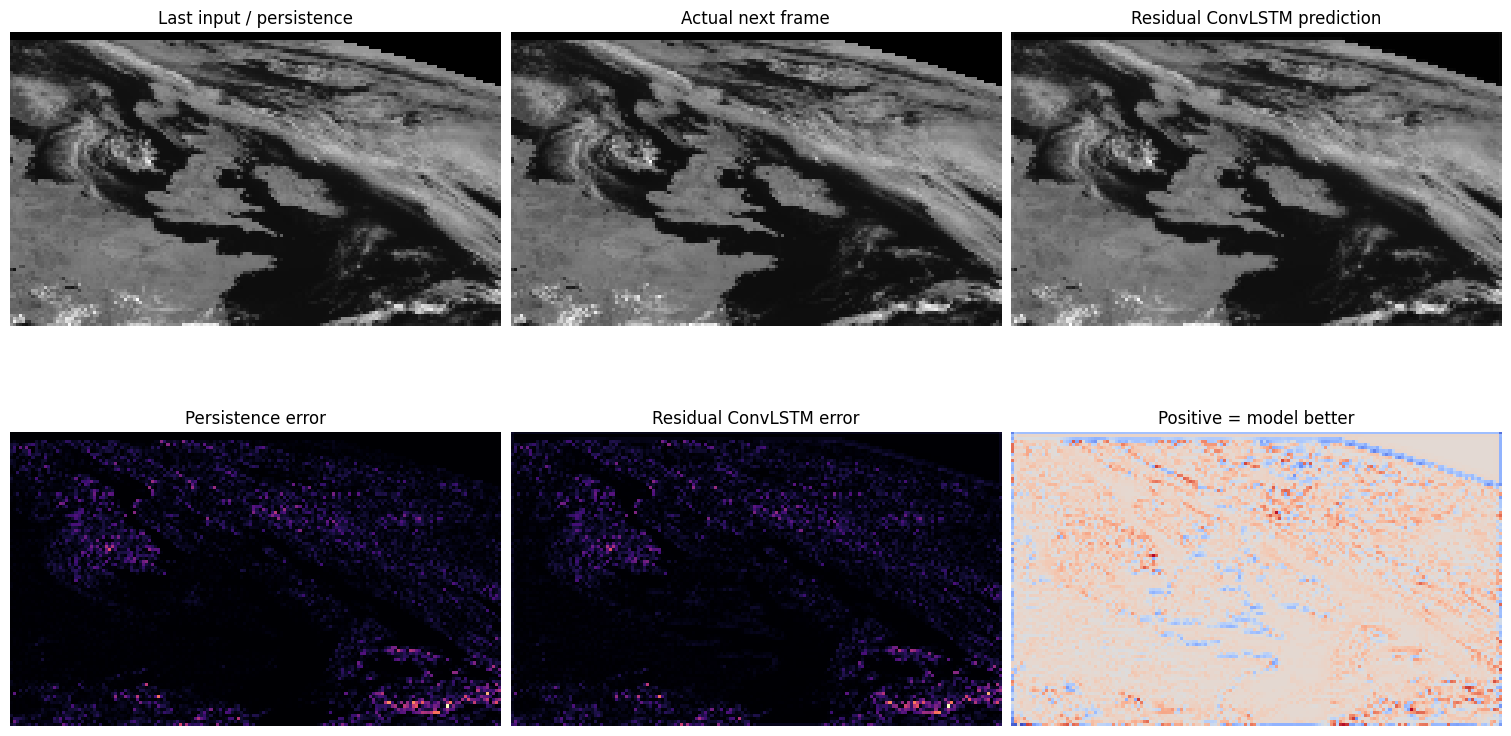

In [49]:
sample_index = 0

last_input = X_eval_small[sample_index, -1, 0].detach().cpu().numpy()
target = y_eval_small[sample_index, 0].detach().cpu().numpy()
res_prediction = y_res_pred[sample_index, 0].detach().cpu().numpy()
persistence_pred = persistence[sample_index, 0].detach().cpu().numpy()

error_res = np.abs(target - res_prediction)
error_persistence = np.abs(target - persistence_pred)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

axes[0, 0].imshow(last_input, cmap="gray", origin="lower")
axes[0, 0].set_title("Last input / persistence")

axes[0, 1].imshow(target, cmap="gray", origin="lower")
axes[0, 1].set_title("Actual next frame")

axes[0, 2].imshow(res_prediction, cmap="gray", origin="lower")
axes[0, 2].set_title("Residual ConvLSTM prediction")

axes[1, 0].imshow(error_persistence, cmap="magma", origin="lower")
axes[1, 0].set_title("Persistence error")

axes[1, 1].imshow(error_res, cmap="magma", origin="lower")
axes[1, 1].set_title("Residual ConvLSTM error")

axes[1, 2].imshow(error_persistence - error_res, cmap="coolwarm", origin="lower")
axes[1, 2].set_title("Positive = model better")

for ax in axes.ravel():
    ax.axis("off")

plt.show()

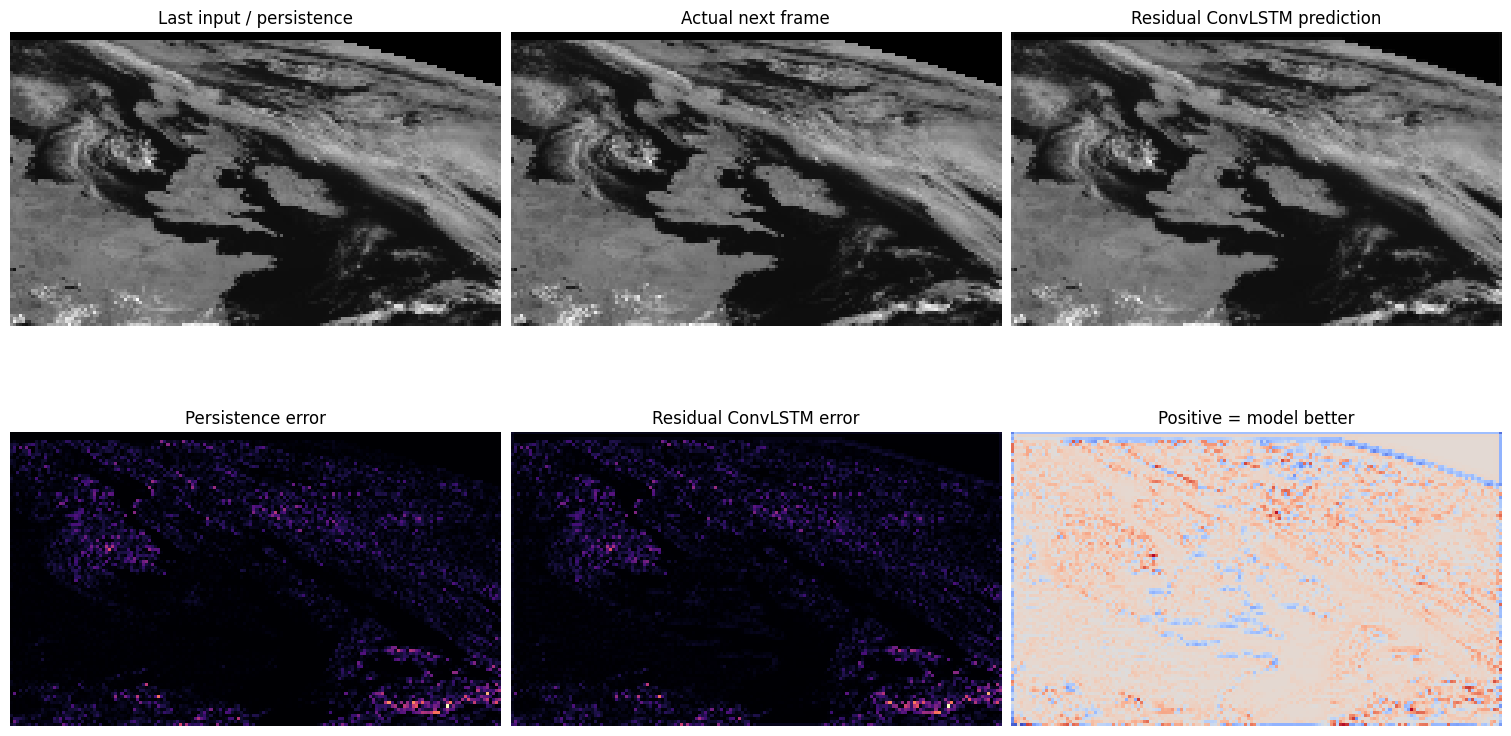

In [50]:
# Plot Residual ConvLSTM, Persistence, And Errors

sample_index = 0

last_input = X_eval_small[sample_index, -1, 0].detach().cpu().numpy()
target = y_eval_small[sample_index, 0].detach().cpu().numpy()
res_prediction = y_res_pred[sample_index, 0].detach().cpu().numpy()
persistence_pred = persistence[sample_index, 0].detach().cpu().numpy()

error_res = np.abs(target - res_prediction)
error_persistence = np.abs(target - persistence_pred)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

axes[0, 0].imshow(last_input, cmap="gray", origin="lower")
axes[0, 0].set_title("Last input / persistence")

axes[0, 1].imshow(target, cmap="gray", origin="lower")
axes[0, 1].set_title("Actual next frame")

axes[0, 2].imshow(res_prediction, cmap="gray", origin="lower")
axes[0, 2].set_title("Residual ConvLSTM prediction")

axes[1, 0].imshow(error_persistence, cmap="magma", origin="lower")
axes[1, 0].set_title("Persistence error")

axes[1, 1].imshow(error_res, cmap="magma", origin="lower")
axes[1, 1].set_title("Residual ConvLSTM error")

axes[1, 2].imshow(error_persistence - error_res, cmap="coolwarm", origin="lower")
axes[1, 2].set_title("Positive = model better")

for ax in axes.ravel():
    ax.axis("off")

plt.show()

In that last panel we can see the difference in the error (error_persistence - error_res)

- positive values = persistence error is larger than model error
- negative values = model error is larger than persistence error

Where red is positive and blue is negative. More red hue means the residual ConvLSTM is better than persistence in more areas.

To make that plot clearer, add a symmetric color scale around zero:


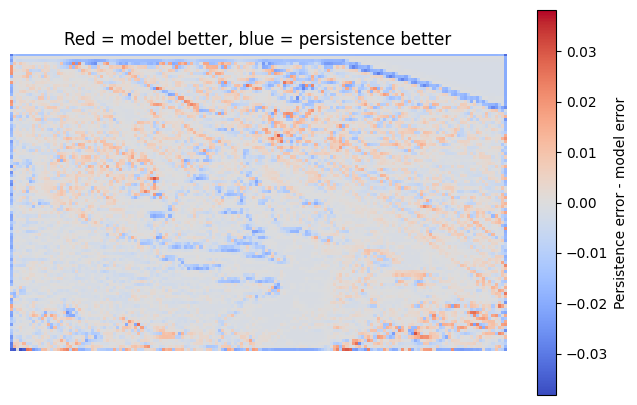

In [52]:
difference = error_persistence - error_res
vmax = np.nanmax(np.abs(difference))

plt.figure(figsize=(8, 5))
plt.imshow(
    difference,
    cmap="coolwarm",
    origin="lower",
    vmin=-vmax,
    vmax=vmax,
)
plt.colorbar(label="Persistence error - model error")
plt.title("Red = model better, blue = persistence better")
plt.axis("off")
plt.show()

## Bidirectional LSTM Models for Satellite Image Prediction

Next, we will build two PyTorch models for satellite image forecasting.

We will do this in two stages:

1. CNN encoder + Bidirectional LSTM + CNN decoder
2. CNN encoder + Bidirectional LSTM + attention + CNN decoder

The main idea is to combine convolutional layers, which are good at learning spatial image features, with recurrent layers, which are good at learning temporal dependencies.


## Stage 1: CNN Encoder + Bidirectional LSTM + CNN Decoder

In the first model, each satellite image is encoded by the CNN encoder. The sequence of encoded features is then passed into a Bidirectional LSTM.

A standard LSTM processes the sequence only forward in time:


x_1 -> x_2 -> ... -> x_T

A Bidirectional LSTM processes the sequence in both directions:

forward direction:   x_1 -> x_2 -> ... -> x_T

backward direction:  x_T -> x_(T-1) -> ... -> x_1

This allows the model to build a richer representation of the input sequence.

For an input sequence:

$$
x_{t-4}, x_{t-3}, x_{t-2}, x_{t-1}, x_t
$$

the CNN encoder produces:

$$
z_{t-4}, z_{t-3}, z_{t-2}, z_{t-1}, z_t
$$

The Bidirectional LSTM then processes these encoded features and produces a temporal representation:

$$
h = \mathrm{BiLSTM}(z_{t-4}, z_{t-3}, z_{t-2}, z_{t-1}, z_t)
$$

Finally, the CNN decoder maps this representation back into image space:

$$
\hat{y}_{t+1} = \mathrm{Decoder}(h)
$$

where y_hat_(t+1) is the predicted next satellite image.

In [53]:
class CNNBiLSTMNextFrame(nn.Module):
    def __init__(self, input_channels=1, latent_dim=128, hidden_dim=64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )

        # For 96 x 160 input:
        # after three stride-2 convolutions: 12 x 20
        self.encoder_fc = nn.Linear(32 * 12 * 20, latent_dim)

        self.lstm = nn.LSTM(
            input_size=latent_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )

        self.decoder_fc = nn.Linear(2 * hidden_dim, 32 * 12 * 20)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(8, 1, kernel_size=4, stride=2, padding=1),
        )

    def forward(self, x):
        # x shape: [batch, time, channels, height, width]

        batch_size, seq_len, channels, height, width = x.shape

        # Encode each image frame separately
        x = x.reshape(batch_size * seq_len, channels, height, width)

        z = self.encoder(x)
        z = z.reshape(batch_size * seq_len, -1)
        z = self.encoder_fc(z)

        # Restore time sequence
        z = z.reshape(batch_size, seq_len, -1)

        # Bidirectional LSTM over the image embeddings
        lstm_out, _ = self.lstm(z)

        # Use the final time-step representation
        final_state = lstm_out[:, -1, :]

        # Decode back to an image
        decoded = self.decoder_fc(final_state)
        decoded = decoded.reshape(batch_size, 32, 12, 20)

        prediction = self.decoder(decoded)

        return prediction

## Train The CNN + Bidirectional LSTM Model

This uses the same `daytime_loader`, `target_size`, `channel_index`, and preprocessing pattern.

In [57]:
bilstm_model = CNNBiLSTMNextFrame(
    input_channels=1,
    latent_dim=128,
    hidden_dim=64,
).to(device)

optimizer_bilstm = torch.optim.Adam(
    bilstm_model.parameters(),
    lr=1e-3,
)

loss_fn = nn.MSELoss()

In [61]:
num_epochs = 15
bilstm_epoch_losses = []

for epoch in range(num_epochs):
    bilstm_model.train()
    batch_losses = []

    for X_batch, y_batch in daytime_loader:
        # Select VIS008
        X_batch = X_batch[:, channel_index:channel_index + 1]
        y_batch = y_batch[:, channel_index:channel_index + 1]

        # [batch, channel, time, height, width]
        # -> [batch, time, channel, height, width]
        X_batch = X_batch.permute(0, 2, 1, 3, 4)
        y_batch = y_batch[:, :, 0]

        batch_size, seq_len, channels, height, width = X_batch.shape

        # Resize X
        X_batch_small = X_batch.reshape(batch_size * seq_len, channels, height, width)
        X_batch_small = F.interpolate(
            X_batch_small,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )
        X_batch_small = X_batch_small.reshape(
            batch_size,
            seq_len,
            channels,
            *target_size,
        )

        # Resize y
        y_batch_small = F.interpolate(
            y_batch,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )

        # Clean NaNs
        X_batch_small = torch.nan_to_num(
            X_batch_small,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        ).to(device)

        y_batch_small = torch.nan_to_num(
            y_batch_small,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        ).to(device)

        optimizer_bilstm.zero_grad()

        y_pred = bilstm_model(X_batch_small)
        loss = loss_fn(y_pred, y_batch_small)

        loss.backward()
        optimizer_bilstm.step()

        batch_losses.append(loss.item())

    mean_loss = np.mean(batch_losses)
    bilstm_epoch_losses.append(mean_loss)

    print(f"Epoch {epoch + 1}/{num_epochs} | mean loss: {mean_loss:.6f}")

Epoch 1/15 | mean loss: 0.029074
Epoch 2/15 | mean loss: 0.029829
Epoch 3/15 | mean loss: 0.031957
Epoch 4/15 | mean loss: 0.029948
Epoch 5/15 | mean loss: 0.028397
Epoch 6/15 | mean loss: 0.027697
Epoch 7/15 | mean loss: 0.027434
Epoch 8/15 | mean loss: 0.027228
Epoch 9/15 | mean loss: 0.026946
Epoch 10/15 | mean loss: 0.026776
Epoch 11/15 | mean loss: 0.026637
Epoch 12/15 | mean loss: 0.026510
Epoch 13/15 | mean loss: 0.026413
Epoch 14/15 | mean loss: 0.026295
Epoch 15/15 | mean loss: 0.026243


In [62]:
bilstm_model.eval()

with torch.no_grad():
    y_bilstm_pred = bilstm_model(X_eval_small)

persistence = X_eval_small[:, -1]

mse_bilstm = loss_fn(y_bilstm_pred, y_eval_small).item()
mse_persistence = loss_fn(persistence, y_eval_small).item()

print("BiLSTM MSE:", mse_bilstm)
print("Persistence MSE:", mse_persistence)

BiLSTM MSE: 0.019127879291772842
Persistence MSE: 0.0009208542760461569


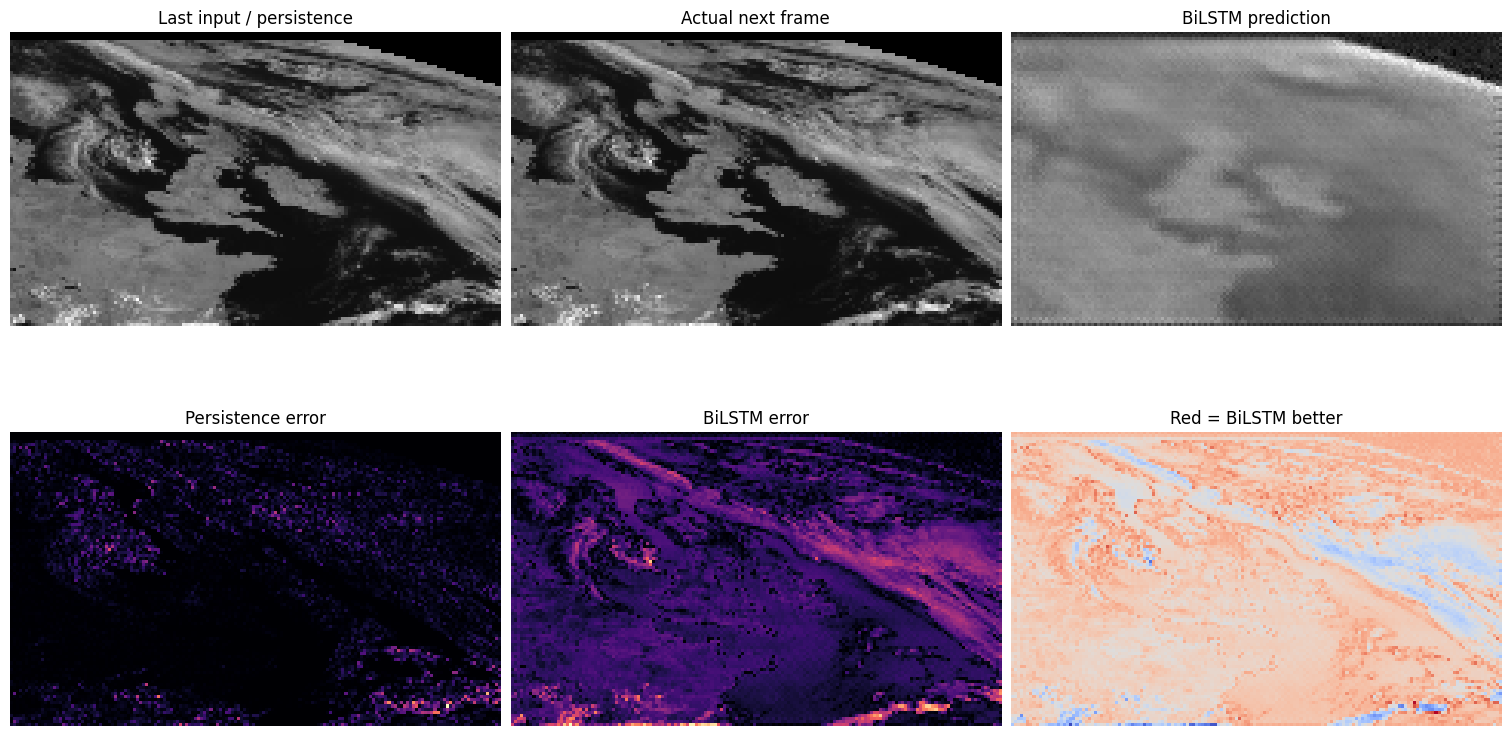

In [63]:
sample_index = 0

last_input = X_eval_small[sample_index, -1, 0].detach().cpu().numpy()
target = y_eval_small[sample_index, 0].detach().cpu().numpy()
prediction = y_bilstm_pred[sample_index, 0].detach().cpu().numpy()
persistence_pred = persistence[sample_index, 0].detach().cpu().numpy()

error_model = np.abs(target - prediction)
error_persistence = np.abs(target - persistence_pred)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

axes[0, 0].imshow(last_input, cmap="gray", origin="lower")
axes[0, 0].set_title("Last input / persistence")

axes[0, 1].imshow(target, cmap="gray", origin="lower")
axes[0, 1].set_title("Actual next frame")

axes[0, 2].imshow(prediction, cmap="gray", origin="lower")
axes[0, 2].set_title("BiLSTM prediction")

axes[1, 0].imshow(error_persistence, cmap="magma", origin="lower")
axes[1, 0].set_title("Persistence error")

axes[1, 1].imshow(error_model, cmap="magma", origin="lower")
axes[1, 1].set_title("BiLSTM error")

axes[1, 2].imshow(error_persistence - error_model, cmap="coolwarm", origin="lower")
axes[1, 2].set_title("Red = BiLSTM better")

for ax in axes.ravel():
    ax.axis("off")

plt.show()

The performance of the residual LSTM is much better than BiLSTM. The reason is the structure of the model:

image -> CNN -> flatten -> one vector -> LSTM -> decoder

A standard LSTM worked well on vector sequences. Satellite images are spatial sequences.

Flattening or compressing images too aggressively loses cloud structure.
ConvLSTM is a better architecture because it keeps height and width throughout the recurrence.

We will improve the residual ConvLSTM in the most sensible order:

1. Use a masked loss instead of replacing NaNs with zeros in the target
2. Increase hidden channels from 16 to 32
3. Train for more epochs
4. Compare against persistence on the same masked pixels

## Update Resolution And Define Masked Loss

This ignores invalid pixels in the target instead of treating missing data as zero.

In [67]:
target_size = (128, 208)

def masked_mse_l1_loss(prediction, target, alpha=0.5):
    """
    Combined masked MSE + L1 loss.

    alpha controls the L1 contribution:
    loss = MSE + alpha * L1

    NaN target pixels are ignored.
    """
    mask = torch.isfinite(target)

    prediction_valid = prediction[mask]
    target_valid = target[mask]

    if target_valid.numel() == 0:
        return torch.tensor(0.0, device=prediction.device)

    mse = torch.mean((prediction_valid - target_valid) ** 2)
    l1 = torch.mean(torch.abs(prediction_valid - target_valid))

    return mse + alpha * l1

### Improved Residual ConvLSTM Model

We will reuse existing `ConvLSTMNextFrame`.

In [68]:
res_model_improved = ResidualConvLSTMNextFrame(
    input_channels=1,
    hidden_channels=32,
    kernel_size=3,
).to(device)

optimizer_res_improved = torch.optim.Adam(
    res_model_improved.parameters(),
    lr=1e-3,
)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### Train Improved Residual ConvLSTM

In [69]:
num_epochs = 20
res_improved_epoch_losses = []

for epoch in range(num_epochs):
    res_model_improved.train()
    batch_losses = []

    for X_batch, y_batch in daytime_loader:
        # Select VIS008
        X_batch = X_batch[:, channel_index:channel_index + 1]
        y_batch = y_batch[:, channel_index:channel_index + 1]

        # [batch, channel, time, height, width]
        # -> [batch, time, channel, height, width]
        X_batch = X_batch.permute(0, 2, 1, 3, 4)
        y_batch = y_batch[:, :, 0]

        batch_size, seq_len, channels, height, width = X_batch.shape

        # Resize X
        X_batch_small = X_batch.reshape(batch_size * seq_len, channels, height, width)

        X_batch_small = F.interpolate(
            X_batch_small,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )

        X_batch_small = X_batch_small.reshape(
            batch_size,
            seq_len,
            channels,
            *target_size,
        )

        # Resize y
        y_batch_small = F.interpolate(
            y_batch,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )

        # The model input cannot contain NaNs.
        # We replace input NaNs with 0.
        X_batch_small_clean = torch.nan_to_num(
            X_batch_small,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        ).to(device)

        # Keep target NaNs for the masked loss.
        y_batch_small = y_batch_small.to(device)

        optimizer_res_improved.zero_grad()

        y_pred = res_model_improved(X_batch_small_clean)

        loss = masked_mse_l1_loss(
            y_pred,
            y_batch_small,
            alpha=0.5,
        )

        loss.backward()
        optimizer_res_improved.step()

        batch_losses.append(loss.item())

    mean_loss = np.mean(batch_losses)
    res_improved_epoch_losses.append(mean_loss)

    print(f"Epoch {epoch + 1:02d}/{num_epochs} | mean loss: {mean_loss:.6f}")

Epoch 01/20 | mean loss: 0.012462
Epoch 02/20 | mean loss: 0.012495
Epoch 03/20 | mean loss: 0.012031
Epoch 04/20 | mean loss: 0.011820
Epoch 05/20 | mean loss: 0.011581
Epoch 06/20 | mean loss: 0.011318
Epoch 07/20 | mean loss: 0.011164
Epoch 08/20 | mean loss: 0.011380
Epoch 09/20 | mean loss: 0.011073
Epoch 10/20 | mean loss: 0.010780
Epoch 11/20 | mean loss: 0.010530
Epoch 12/20 | mean loss: 0.010203
Epoch 13/20 | mean loss: 0.010042
Epoch 14/20 | mean loss: 0.010021
Epoch 15/20 | mean loss: 0.009787
Epoch 16/20 | mean loss: 0.009807
Epoch 17/20 | mean loss: 0.009625
Epoch 18/20 | mean loss: 0.009624
Epoch 19/20 | mean loss: 0.009569
Epoch 20/20 | mean loss: 0.009516


In [72]:
## Define Masked MSE Metric

def masked_mse_metric(prediction, target):
    mask = torch.isfinite(target)

    prediction_valid = prediction[mask]
    target_valid = target[mask]

    if target_valid.numel() == 0:
        return torch.tensor(float("nan"), device=prediction.device)

    return torch.mean((prediction_valid - target_valid) ** 2)

In [76]:
channel_index = 8  # VIS008
target_size = (128, 208)

X_eval_raw, y_eval_raw = next(iter(daytime_loader))

print("Raw X:", X_eval_raw.shape)
print("Raw y:", y_eval_raw.shape)

# Select VIS008
X_eval_vis = X_eval_raw[:, channel_index:channel_index + 1]
y_eval_vis = y_eval_raw[:, channel_index:channel_index + 1]

print("Selected X:", X_eval_vis.shape)
print("Selected y:", y_eval_vis.shape)

# Rearrange X: [batch, channel, time, height, width]
# -> [batch, time, channel, height, width]
X_eval_vis = X_eval_vis.permute(0, 2, 1, 3, 4)

# Remove forecast time dimension from y
y_eval_vis = y_eval_vis[:, :, 0]

print("Rearranged X:", X_eval_vis.shape)
print("Rearranged y:", y_eval_vis.shape)

batch_size, seq_len, channels, height, width = X_eval_vis.shape

X_eval_resized = X_eval_vis.reshape(batch_size * seq_len, channels, height, width)

print("Before resize X:", X_eval_resized.shape)

X_eval_resized = F.interpolate(
    X_eval_resized,
    size=target_size,
    mode="bilinear",
    align_corners=False,
)

X_eval_resized = X_eval_resized.reshape(
    batch_size,
    seq_len,
    channels,
    *target_size,
)

y_eval_resized = F.interpolate(
    y_eval_vis,
    size=target_size,
    mode="bilinear",
    align_corners=False,
)

X_eval_clean = torch.nan_to_num(
    X_eval_resized,
    nan=0.0,
    posinf=0.0,
    neginf=0.0,
).to(device)

y_eval_resized = y_eval_resized.to(device)

print("Final X_eval_clean:", X_eval_clean.shape)
print("Final y_eval_resized:", y_eval_resized.shape)

Raw X: torch.Size([8, 11, 5, 372, 614])
Raw y: torch.Size([8, 11, 1, 372, 614])
Selected X: torch.Size([8, 1, 5, 372, 614])
Selected y: torch.Size([8, 1, 1, 372, 614])
Rearranged X: torch.Size([8, 5, 1, 372, 614])
Rearranged y: torch.Size([8, 1, 372, 614])
Before resize X: torch.Size([40, 1, 372, 614])
Final X_eval_clean: torch.Size([8, 5, 1, 128, 208])
Final y_eval_resized: torch.Size([8, 1, 128, 208])


In [77]:
print("Length of daytime_dataset:", len(daytime_dataset))

for batch_idx, (X_eval, y_eval) in enumerate(daytime_loader):
    print("Batch index:", batch_idx)
    print("X_eval shape:", X_eval.shape)
    print("y_eval shape:", y_eval.shape)
    break

Length of daytime_dataset: 395
Batch index: 0
X_eval shape: torch.Size([8, 11, 5, 372, 614])
y_eval shape: torch.Size([8, 11, 1, 372, 614])


In [78]:
## Improved Residual ConvLSTM Versus Persistence

res_model_improved.eval()

with torch.no_grad():
    y_pred_improved = res_model_improved(X_eval_clean)

persistence = X_eval_clean[:, -1]

mse_improved = masked_mse_metric(y_pred_improved, y_eval_resized).item()
mse_persistence = masked_mse_metric(persistence, y_eval_resized).item()

print("Improved residual ConvLSTM masked MSE:", mse_improved)
print("Persistence masked MSE:", mse_persistence)

Improved residual ConvLSTM masked MSE: 0.0008380042272619903
Persistence masked MSE: 0.0010386112844571471


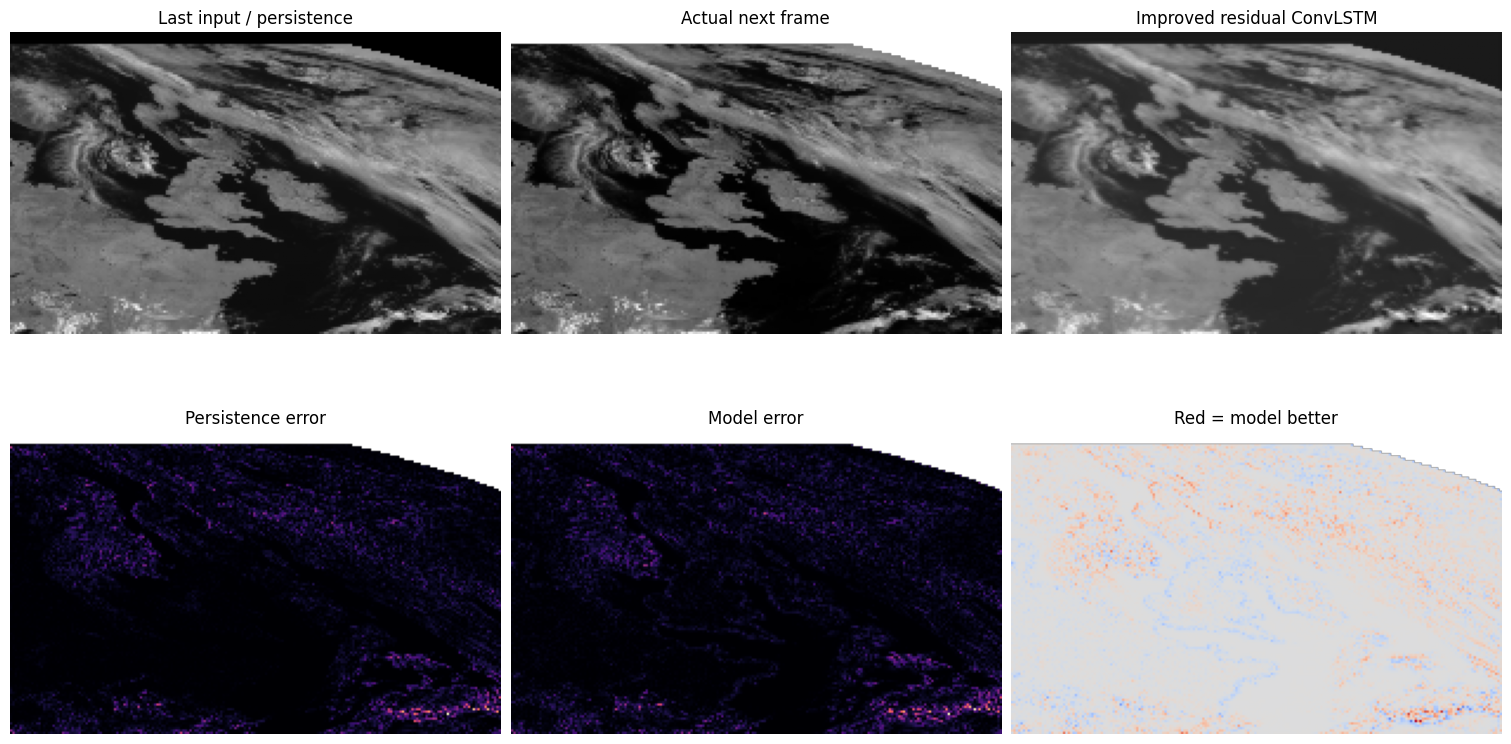

In [79]:
sample_index = 0

last_input = X_eval_clean[sample_index, -1, 0].detach().cpu().numpy()
target = y_eval_resized[sample_index, 0].detach().cpu().numpy()
prediction = y_pred_improved[sample_index, 0].detach().cpu().numpy()
persistence_pred = persistence[sample_index, 0].detach().cpu().numpy()

error_model = np.abs(target - prediction)
error_persistence = np.abs(target - persistence_pred)

difference = error_persistence - error_model
vmax = np.nanmax(np.abs(difference))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

axes[0, 0].imshow(last_input, cmap="gray", origin="lower")
axes[0, 0].set_title("Last input / persistence")

axes[0, 1].imshow(target, cmap="gray", origin="lower")
axes[0, 1].set_title("Actual next frame")

axes[0, 2].imshow(prediction, cmap="gray", origin="lower")
axes[0, 2].set_title("Improved residual ConvLSTM")

axes[1, 0].imshow(error_persistence, cmap="magma", origin="lower")
axes[1, 0].set_title("Persistence error")

axes[1, 1].imshow(error_model, cmap="magma", origin="lower")
axes[1, 1].set_title("Model error")

axes[1, 2].imshow(
    difference,
    cmap="coolwarm",
    origin="lower",
    vmin=-vmax,
    vmax=vmax,
)
axes[1, 2].set_title("Red = model better")

for ax in axes.ravel():
    ax.axis("off")

plt.show()

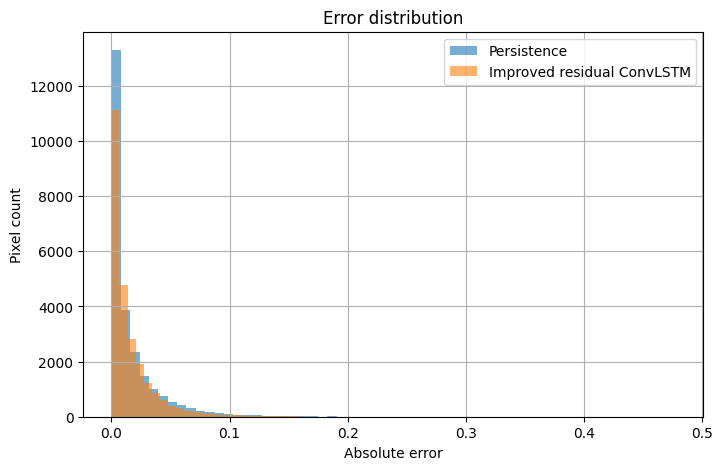

In [80]:
model_error_values = error_model[np.isfinite(error_model)].ravel()
persistence_error_values = error_persistence[np.isfinite(error_persistence)].ravel()

plt.figure(figsize=(8, 5))
plt.hist(
    persistence_error_values,
    bins=60,
    alpha=0.6,
    label="Persistence",
)
plt.hist(
    model_error_values,
    bins=60,
    alpha=0.6,
    label="Improved residual ConvLSTM",
)
plt.xlabel("Absolute error")
plt.ylabel("Pixel count")
plt.title("Error distribution")
plt.legend()
plt.grid(True)
plt.show()

In [81]:
print("Mean absolute error")
print("Persistence:", np.mean(persistence_error_values))
print("Model:", np.mean(model_error_values))

print("\n95th percentile absolute error")
print("Persistence:", np.percentile(persistence_error_values, 95))
print("Model:", np.percentile(model_error_values, 95))

print("\n99th percentile absolute error")
print("Persistence:", np.percentile(persistence_error_values, 99))
print("Model:", np.percentile(model_error_values, 99))

Mean absolute error
Persistence: 0.016474107
Model: 0.01579359

95th percentile absolute error
Persistence: 0.06360267
Model: 0.05521948

99th percentile absolute error
Persistence: 0.11591158
Model: 0.10003143


## Define Masked Gradient Loss

To address blur, we will add a gradient loss. MSE/L1 that we used earlier compares pixel values. Gradient loss compares image edges and spatial changes. So it encourages sharper cloud boundaries.

For a target image \(y\) and prediction \(\hat{y}\), compare horizontal and vertical gradients:

$$
\nabla_x \hat{y} \approx \nabla_x y
$$

$$
\nabla_y \hat{y} \approx \nabla_y y
$$

This should make the prediction less smooth.

In [83]:
def image_gradients(img):
    """
    img shape: [batch, channels, height, width]
    """
    grad_x = img[:, :, :, 1:] - img[:, :, :, :-1]
    grad_y = img[:, :, 1:, :] - img[:, :, :-1, :]

    return grad_x, grad_y


def masked_gradient_loss(prediction, target):
    pred_x, pred_y = image_gradients(prediction)
    target_x, target_y = image_gradients(target)

    mask_x = torch.isfinite(target_x)
    mask_y = torch.isfinite(target_y)

    loss_x = torch.mean(torch.abs(pred_x[mask_x] - target_x[mask_x]))
    loss_y = torch.mean(torch.abs(pred_y[mask_y] - target_y[mask_y]))

    return loss_x + loss_y

## Define Combined Loss With Gradient Term

In [84]:
def masked_mse_l1_gradient_loss(
    prediction,
    target,
    alpha_l1=0.1,
    beta_gradient=0.1,
):
    mask = torch.isfinite(target)

    prediction_valid = prediction[mask]
    target_valid = target[mask]

    mse = torch.mean((prediction_valid - target_valid) ** 2)
    l1 = torch.mean(torch.abs(prediction_valid - target_valid))
    grad = masked_gradient_loss(prediction, target)

    return mse + alpha_l1 * l1 + beta_gradient * grad

## Train A Sharper Residual ConvLSTMn

In [85]:
res_model_sharp = ResidualConvLSTMNextFrame(
    input_channels=1,
    hidden_channels=32,
    kernel_size=3,
).to(device)

optimizer_res_sharp = torch.optim.Adam(
    res_model_sharp.parameters(),
    lr=1e-3,
)

num_epochs = 20
res_sharp_epoch_losses = []

for epoch in range(num_epochs):
    res_model_sharp.train()
    batch_losses = []

    for X_batch, y_batch in daytime_loader:
        # Select VIS008
        X_batch = X_batch[:, channel_index:channel_index + 1]
        y_batch = y_batch[:, channel_index:channel_index + 1]

        # Rearrange
        X_batch = X_batch.permute(0, 2, 1, 3, 4)
        y_batch = y_batch[:, :, 0]

        batch_size, seq_len, channels, height, width = X_batch.shape

        # Resize X
        X_batch_small = X_batch.reshape(batch_size * seq_len, channels, height, width)

        X_batch_small = F.interpolate(
            X_batch_small,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )

        X_batch_small = X_batch_small.reshape(
            batch_size,
            seq_len,
            channels,
            *target_size,
        )

        # Resize y
        y_batch_small = F.interpolate(
            y_batch,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )

        # Clean input only
        X_batch_small_clean = torch.nan_to_num(
            X_batch_small,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        ).to(device)

        y_batch_small = y_batch_small.to(device)

        optimizer_res_sharp.zero_grad()

        y_pred = res_model_sharp(X_batch_small_clean)

        loss = masked_mse_l1_gradient_loss(
            y_pred,
            y_batch_small,
            alpha_l1=0.1,
            beta_gradient=0.1,
        )

        loss.backward()
        optimizer_res_sharp.step()

        batch_losses.append(loss.item())

    mean_loss = np.mean(batch_losses)
    res_sharp_epoch_losses.append(mean_loss)

    print(f"Epoch {epoch + 1:02d}/{num_epochs} | mean loss: {mean_loss:.6f}")

Epoch 01/20 | mean loss: 0.012289
Epoch 02/20 | mean loss: 0.008570
Epoch 03/20 | mean loss: 0.008423
Epoch 04/20 | mean loss: 0.008256
Epoch 05/20 | mean loss: 0.008315
Epoch 06/20 | mean loss: 0.008084
Epoch 07/20 | mean loss: 0.008009
Epoch 08/20 | mean loss: 0.007958
Epoch 09/20 | mean loss: 0.007865
Epoch 10/20 | mean loss: 0.007774
Epoch 11/20 | mean loss: 0.007626
Epoch 12/20 | mean loss: 0.007460
Epoch 13/20 | mean loss: 0.007317
Epoch 14/20 | mean loss: 0.007447
Epoch 15/20 | mean loss: 0.007523
Epoch 16/20 | mean loss: 0.007192
Epoch 17/20 | mean loss: 0.007144
Epoch 18/20 | mean loss: 0.006941
Epoch 19/20 | mean loss: 0.006843
Epoch 20/20 | mean loss: 0.006837


## Evaluate Sharp Residual ConvLSTM

In [86]:
res_model_sharp.eval()

with torch.no_grad():
    y_pred_sharp = res_model_sharp(X_eval_clean)

persistence = X_eval_clean[:, -1]

mse_sharp = masked_mse_metric(y_pred_sharp, y_eval_resized).item()
mse_persistence = masked_mse_metric(persistence, y_eval_resized).item()

print("Sharp residual ConvLSTM masked MSE:", mse_sharp)
print("Persistence masked MSE:", mse_persistence)

Sharp residual ConvLSTM masked MSE: 0.0008998078992590308
Persistence masked MSE: 0.0010386112844571471


In [87]:
sample_index = 0

target = y_eval_resized[sample_index, 0].detach().cpu().numpy()
sharp_prediction = y_pred_sharp[sample_index, 0].detach().cpu().numpy()
persistence_pred = persistence[sample_index, 0].detach().cpu().numpy()

error_sharp = np.abs(target - sharp_prediction)
error_persistence = np.abs(target - persistence_pred)

sharp_error_values = error_sharp[np.isfinite(error_sharp)].ravel()
persistence_error_values = error_persistence[np.isfinite(error_persistence)].ravel()

print("Mean absolute error")
print("Persistence:", np.mean(persistence_error_values))
print("Sharp model:", np.mean(sharp_error_values))

print("\n95th percentile absolute error")
print("Persistence:", np.percentile(persistence_error_values, 95))
print("Sharp model:", np.percentile(sharp_error_values, 95))

print("\n99th percentile absolute error")
print("Persistence:", np.percentile(persistence_error_values, 99))
print("Sharp model:", np.percentile(sharp_error_values, 99))

Mean absolute error
Persistence: 0.016474107
Sharp model: 0.017065724

95th percentile absolute error
Persistence: 0.06360267
Sharp model: 0.05728482

99th percentile absolute error
Persistence: 0.11591158
Sharp model: 0.10230499


Previous improved residual model:
- Mean absolute error: 0.01579
- 95th percentile:     0.05522
- 99th percentile:     0.10003

Sharp gradient model:
- Mean absolute error: 0.01707
- 95th percentile:     0.05728
- 99th percentile:     0.10230
So the gradient-loss model is not better numerically. It may look slightly sharper, but the earlier improved residual model is stronger overall.

Best model so far: improved residual ConvLSTM with hidden_channels=32, target_size=(128, 208), masked MSE + L1.


## Stacked LSTM

- Layer 1: 32 hidden channels
- Layer 2: 16 hidden channels
- Residual output
- Target size: 128 x 208
- Loss: masked MSE + 0.5 * masked L1

In [88]:
class StackedResidualConvLSTMNextFrame(nn.Module):
    def __init__(
        self,
        input_channels=1,
        hidden_channels_1=32,
        hidden_channels_2=16,
        kernel_size=3,
    ):
        super().__init__()

        self.hidden_channels_1 = hidden_channels_1
        self.hidden_channels_2 = hidden_channels_2

        self.cell1 = ConvLSTMCell(
            input_channels=input_channels,
            hidden_channels=hidden_channels_1,
            kernel_size=kernel_size,
        )

        self.cell2 = ConvLSTMCell(
            input_channels=hidden_channels_1,
            hidden_channels=hidden_channels_2,
            kernel_size=kernel_size,
        )

        self.output_conv = nn.Conv2d(
            in_channels=hidden_channels_2,
            out_channels=input_channels,
            kernel_size=1,
        )

    def forward(self, x):
        # x shape: [batch, time, channels, height, width]

        batch_size, seq_len, channels, height, width = x.shape

        h1 = torch.zeros(
            batch_size,
            self.hidden_channels_1,
            height,
            width,
            device=x.device,
        )
        c1 = torch.zeros_like(h1)

        h2 = torch.zeros(
            batch_size,
            self.hidden_channels_2,
            height,
            width,
            device=x.device,
        )
        c2 = torch.zeros_like(h2)

        for t in range(seq_len):
            h1, c1 = self.cell1(x[:, t], h1, c1)
            h2, c2 = self.cell2(h1, h2, c2)

        residual = self.output_conv(h2)

        last_frame = x[:, -1]

        prediction = last_frame + residual

        return prediction

## Create The Stacked Model And Optimizer

In [89]:
stacked_model = StackedResidualConvLSTMNextFrame(
    input_channels=1,
    hidden_channels_1=32,
    hidden_channels_2=16,
    kernel_size=3,
).to(device)

optimizer_stacked = torch.optim.Adam(
    stacked_model.parameters(),
    lr=1e-3,
)

print(stacked_model)

StackedResidualConvLSTMNextFrame(
  (cell1): ConvLSTMCell(
    (conv): Conv2d(33, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (cell2): ConvLSTMCell(
    (conv): Conv2d(48, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (output_conv): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1))
)


### Quick Forward-Pass Test

Before training, check that it produces the right shape on the eval batch:

In [90]:
stacked_model.eval()

with torch.no_grad():
    y_test_pred = stacked_model(X_eval_clean)

print("Prediction shape:", y_test_pred.shape)
print("Target shape:", y_eval_resized.shape)

Prediction shape: torch.Size([8, 1, 128, 208])
Target shape: torch.Size([8, 1, 128, 208])


### Train The Stacked Residual ConvLSTM

We’ll use the same improved loss as the current best model:

In [91]:
num_epochs = 20
stacked_epoch_losses = []

for epoch in range(num_epochs):
    stacked_model.train()
    batch_losses = []

    for X_batch, y_batch in daytime_loader:
        # Select VIS008
        X_batch = X_batch[:, channel_index:channel_index + 1]
        y_batch = y_batch[:, channel_index:channel_index + 1]

        # [batch, channel, time, height, width]
        # -> [batch, time, channel, height, width]
        X_batch = X_batch.permute(0, 2, 1, 3, 4)
        y_batch = y_batch[:, :, 0]

        batch_size, seq_len, channels, height, width = X_batch.shape

        # Resize X
        X_batch_small = X_batch.reshape(batch_size * seq_len, channels, height, width)

        X_batch_small = F.interpolate(
            X_batch_small,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )

        X_batch_small = X_batch_small.reshape(
            batch_size,
            seq_len,
            channels,
            *target_size,
        )

        # Resize y
        y_batch_small = F.interpolate(
            y_batch,
            size=target_size,
            mode="bilinear",
            align_corners=False,
        )

        # Clean input only
        X_batch_small_clean = torch.nan_to_num(
            X_batch_small,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        ).to(device)

        # Keep target NaNs for masked loss
        y_batch_small = y_batch_small.to(device)

        optimizer_stacked.zero_grad()

        y_pred = stacked_model(X_batch_small_clean)

        loss = masked_mse_l1_loss(
            y_pred,
            y_batch_small,
            alpha=0.5,
        )

        loss.backward()
        optimizer_stacked.step()

        batch_losses.append(loss.item())

    mean_loss = np.mean(batch_losses)
    stacked_epoch_losses.append(mean_loss)

    print(f"Epoch {epoch + 1:02d}/{num_epochs} | mean loss: {mean_loss:.6f}")

Epoch 01/20 | mean loss: 0.012871
Epoch 02/20 | mean loss: 0.012113
Epoch 03/20 | mean loss: 0.012033
Epoch 04/20 | mean loss: 0.011938
Epoch 05/20 | mean loss: 0.012037
Epoch 06/20 | mean loss: 0.011769
Epoch 07/20 | mean loss: 0.011690
Epoch 08/20 | mean loss: 0.011625
Epoch 09/20 | mean loss: 0.011270
Epoch 10/20 | mean loss: 0.010826
Epoch 11/20 | mean loss: 0.010545
Epoch 12/20 | mean loss: 0.010577
Epoch 13/20 | mean loss: 0.010529
Epoch 14/20 | mean loss: 0.010179
Epoch 15/20 | mean loss: 0.009896
Epoch 16/20 | mean loss: 0.009778
Epoch 17/20 | mean loss: 0.009783
Epoch 18/20 | mean loss: 0.009542
Epoch 19/20 | mean loss: 0.009463
Epoch 20/20 | mean loss: 0.009446


## Evaluate Stacked Residual ConvLSTM

In [92]:
stacked_model.eval()

with torch.no_grad():
    y_pred_stacked = stacked_model(X_eval_clean)

persistence = X_eval_clean[:, -1]

mse_stacked = masked_mse_metric(y_pred_stacked, y_eval_resized).item()
mse_persistence = masked_mse_metric(persistence, y_eval_resized).item()

print("Stacked residual ConvLSTM masked MSE:", mse_stacked)
print("Persistence masked MSE:", mse_persistence)

Stacked residual ConvLSTM masked MSE: 0.000890758412424475
Persistence masked MSE: 0.0010386112844571471


In [93]:
# Error Summary For Stacked Model

sample_index = 0

target = y_eval_resized[sample_index, 0].detach().cpu().numpy()
stacked_prediction = y_pred_stacked[sample_index, 0].detach().cpu().numpy()
persistence_pred = persistence[sample_index, 0].detach().cpu().numpy()

error_stacked = np.abs(target - stacked_prediction)
error_persistence = np.abs(target - persistence_pred)

stacked_error_values = error_stacked[np.isfinite(error_stacked)].ravel()
persistence_error_values = error_persistence[np.isfinite(error_persistence)].ravel()

print("Mean absolute error")
print("Persistence:", np.mean(persistence_error_values))
print("Stacked model:", np.mean(stacked_error_values))

print("\n95th percentile absolute error")
print("Persistence:", np.percentile(persistence_error_values, 95))
print("Stacked model:", np.percentile(stacked_error_values, 95))

print("\n99th percentile absolute error")
print("Persistence:", np.percentile(persistence_error_values, 99))
print("Stacked model:", np.percentile(stacked_error_values, 99))

Mean absolute error
Persistence: 0.016474107
Stacked model: 0.017034097

95th percentile absolute error
Persistence: 0.06360267
Stacked model: 0.057170074

99th percentile absolute error
Persistence: 0.11591158
Stacked model: 0.1029024


Overall, we trained the following models, sorted by their performance:

1. Improved residual ConvLSTM, hidden=32, MSE + 0.5 L1: best overall
2. Stacked residual ConvLSTM: beats persistence, helps large errors
3. Sharp gradient-loss ConvLSTM: similar to stacked
4. Persistence baseline
5. Plain ConvLSTM
6. CNN + BiLSTM